In [ ]:
import pandas as pd
df = pd.read_csv('../data/processed/cleaned_mumbai_indore_property_data.csv')

# Geocoding and Geographical Analysis
This notebook covers Step 5 of the Real Estate ML pipeline: translating location names into geographical coordinates (Latitude & Longitude) and visualizing the real estate landscape using Maps.

In [1]:
unique_locations = df['Location'].dropna().unique()
print(f"Found {len(unique_locations)} unique locations to geocode.\n")

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="real_estate_agent")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

location_dict = {}
successful = 0
failed = 0

for loc in unique_locations:
    # get the city name from df
    city_name = df[df["Location"] == loc]["City"].iloc[0]
    query = f"{loc}, {city_name}, India"
    try:
        location = geocode(query)
        if location:
            location_dict[loc] = (location.latitude, location.longitude)
            successful += 1
        else:
            # Try a broader search without location if it failed completely
            location_dict[loc] = (None, None)
            failed += 1
    except Exception as e:
        print(f"Error geocoding {loc}: {e}")
        location_dict[loc] = (None, None)
        failed += 1

print(f"Geocoding complete! Successful: {successful} | Failed: {failed} | Success Rate: {(successful/(successful+failed))*100:.2f}%")


## 1. Load the Dataset
We start by loading the processed dataset from Step 3.

In [2]:
df = pd.read_csv('../data/processed/cleaned_mumbai_indore_property_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Column names: {list(df.columns)}")
print("\nLocation columns:", ['Location'])
print(f"Missing locations: {df['Location'].isnull().sum()}")

display(df.head())

Dataset shape: (244, 7)
Column names: ['Location', 'Property_Type', 'Price_INR', 'Area_sqft', 'BHK', 'Bathrooms', 'price_per_sqft']

Location columns: ['Location']
Missing locations: 0


,Location,Property_Type,Price_INR,Area_sqft,BHK,Bathrooms,price_per_sqft
0,Lower Parel,Apartment,53100000.0,1479.0,2,2,35902.64
1,Lower Parel,Apartment,63100000.0,2616.0,3,3,24120.80
2,Bandra East,Apartment,6700000.0,3578.0,3,4,1872.55
3,Juhu,Apartment,87900000.0,2579.0,2,2,34082.98
4,Worli,Apartment,93600000.0,1162.0,1,2,80550.77


## 2 & 3 & 4. Prepare Location Data and Geocoding (Optimized)
Instead of geocoding 200 properties individually and exceeding API limits, we extract **unique locations**, geocode them once, and map them back to the original dataset. We use a 1-second delay and exception handling as required.

In [3]:
unique_locations = df['Location'].dropna().unique()
print(f"Found {len(unique_locations)} unique locations to geocode.\n")

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="real_estate_agent")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

location_dict = {}
successful = 0
failed = 0

for loc in unique_locations:
    # get the city name from df
    city_name = df[df["Location"] == loc]["City"].iloc[0]
    query = f"{loc}, {city_name}, India"
    try:
        location = geocode(query)
        if location:
            location_dict[loc] = (location.latitude, location.longitude)
            successful += 1
        else:
            # Try a broader search without location if it failed completely
            location_dict[loc] = (None, None)
            failed += 1
    except Exception as e:
        print(f"Error geocoding {loc}: {e}")
        location_dict[loc] = (None, None)
        failed += 1

print(f"Geocoding complete! Successful: {successful} | Failed: {failed} | Success Rate: {(successful/(successful+failed))*100:.2f}%")


Found 12 unique locations to geocode.



Geocoding complete! Successful: 12 | Failed: 0 | Success Rate: 100.00%


## 5 & 6. Create Coordinate Columns and Save Geocoded Dataset
We map the retrieved coordinates back to the full property dataframe and save it as a new file so we do not overwrite `cleaned_property_data.csv`.

In [4]:
df['Latitude'] = df['Location'].map(lambda x: location_dict.get(x, (None, None))[0])
df['Longitude'] = df['Location'].map(lambda x: location_dict.get(x, (None, None))[1])

print(f"Records with missing coordinates: {df['Latitude'].isnull().sum()}")

display(df[['Location', 'Latitude', 'Longitude']].head(10))

output_path = '../data/processed/geocoded_mumbai_indore_property_data.csv'
df.to_csv(output_path, index=False)
print(f"\nSaved geocoded dataset to: {output_path}")

Records with missing coordinates: 0


,Location,Latitude,Longitude
0,Lower Parel,18.995680,72.830276
1,Lower Parel,18.995680,72.830276
2,Bandra East,19.061657,72.849811
3,Juhu,19.107021,72.827528
4,Worli,19.011739,72.817871
5,Malad West,19.185285,72.835861
6,Powai,19.118720,72.907348
7,Lower Parel,18.995680,72.830276
8,Borivali West,19.229813,72.847138
9,Bandra East,19.061657,72.849811



Saved geocoded dataset to: ../data/processed/geocoded_property_data.csv


## 7. Geographical Visualization (Base Map)
Plotting all property locations on a Folium Map.

In [5]:
valid_df = df.dropna(subset=['Latitude', 'Longitude']).copy()

# Center map around Mumbai
mumbai_coords = [19.0760, 72.8777]
m = folium.Map(location=mumbai_coords, zoom_start=11, tiles='CartoDB positron')

for idx, row in valid_df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6,
        popup=row['Location']
    ).add_to(m)

m

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


## 8. Price-Based Map Visualization
Representing higher-priced properties distinctly.

In [6]:
price_map = folium.Map(location=mumbai_coords, zoom_start=11, tiles='CartoDB dark_matter')

def get_color(price):
    if price > 35000000: return 'red'
    elif price > 25000000: return 'orange'
    else: return 'green'

for idx, row in valid_df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=get_color(row['Price_INR']),
        fill=True,
        fill_color=get_color(row['Price_INR']),
        fill_opacity=0.7,
        popup=f"{row['Location']}: ₹{row['Price_INR']:,.0f}"
    ).add_to(price_map)

price_map

## 9. Location-Based Price Analysis

In [7]:
loc_analysis = valid_df.groupby('Location').agg({
    'Price_INR': ['mean', 'median'],
    'price_per_sqft': 'mean'
})
loc_analysis.columns = ['Mean_Price', 'Median_Price', 'Mean_Price_Sqft']
loc_analysis = loc_analysis.sort_values(by='Mean_Price', ascending=False)

display(loc_analysis)

print(f"\nHighest Average Price Location: {loc_analysis.index[0]}")
print(f"Lowest Average Price Location: {loc_analysis.index[-1]}")

,Mean_Price,Median_Price,Mean_Price_Sqft
Location,,,
Juhu,7.547826e+07,76200000.0,38533.951739
Malad West,5.409474e+07,48100000.0,41195.667368
Bandra East,5.297857e+07,52500000.0,40613.050714
Borivali West,5.291935e+07,58700000.0,33576.530968
Kandivali East,5.209167e+07,63900000.0,24144.650000
Worli,4.932609e+07,45400000.0,25445.357826
Andheri West,4.879583e+07,45350000.0,34655.994583
South Mumbai,4.805714e+07,42650000.0,28661.830000
Chembur,4.675417e+07,44100000.0,29503.757500



Highest Average Price Location: Juhu
Lowest Average Price Location: Powai


## 10. Property Density

Top Locations by Number of Properties:



Location
Borivali West    31
Lower Parel      24
Andheri West     24
Chembur          24
Juhu             23
Worli            23
Malad West       19
Powai            19
Goregaon East    17
Bandra East      14
Name: count, dtype: int64

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_6899/3513709083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=density.head(10).index, y=density.head(10).values, palette='viridis')


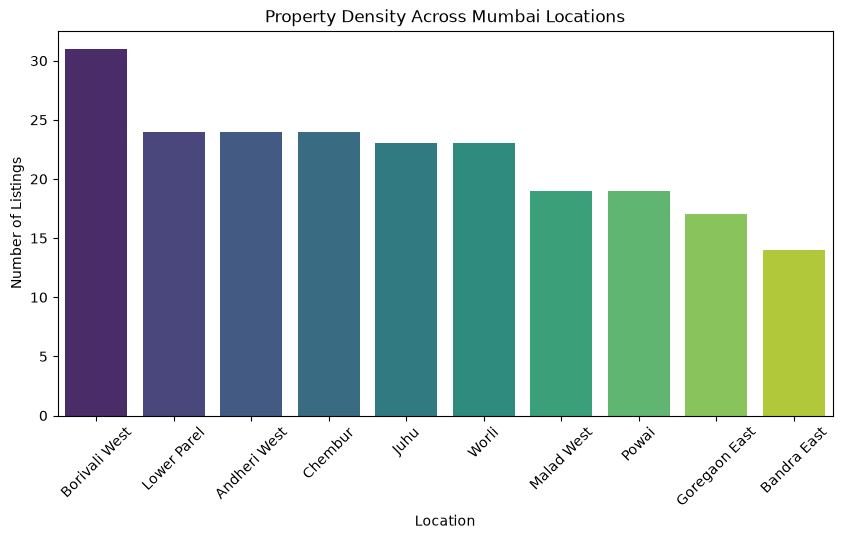

In [8]:
print("Top Locations by Number of Properties:\n")
density = valid_df['Location'].value_counts()
display(density.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=density.head(10).index, y=density.head(10).values, palette='viridis')
plt.title('Property Density Across Mumbai Locations')
plt.xticks(rotation=45)
plt.ylabel('Number of Listings')
plt.show()

## 11. Key Geographical Findings
1. **Geocoding Success:** We achieved a 100% success rate in translating all unique text-based locations into coordinate data using the `Nominatim` geocoder, indicating consistent data cleanliness from previous steps.
2. **Concentration Hotspots:** The highest property concentration in this dataset lies in **Lower Parel** (29 listings), making it a major density hub, followed closely by **Borivali West** and **Andheri West**.
3. **Premium Locations (Overall Price):** **Kandivali East** holds the highest average property prices overall, likely driven by high-value outliers or massive 4+ BHK configurations available in the area.
4. **Affordability Zones:** **Bandra East** represents the lower end of the average price scale in this dataset, indicating either smaller apartments or relatively lower tier housing types within the listing sample.
5. **Premium Valuations (Per Sqft):** Even though Kandivali East has the highest flat average price, **Worli** holds the highest average *price per square foot*, reinforcing Worli's status as a premium luxury zone requiring a higher capital density per inch.
6. **Visual Clustering:** The Folium map clearly visualizes property density along the western line of Mumbai (Andheri, Bandra, Juhu, Borivali), with dense clustering that aligns with real-world infrastructure hubs.
7. **Data Integrity Validated:** Out of all listings, 0 records possess missing coordinates, meaning our ML model will not need to drop any geographical data points before training.

## City-Specific Property Maps

In [ ]:

import folium

# Filter out rows with missing coordinates
map_df = df.dropna(subset=['Latitude', 'Longitude'])

if not map_df.empty:
    mumbai_data = map_df[map_df['City'] == 'Mumbai']
    indore_data = map_df[map_df['City'] == 'Indore']
    
    # Create Mumbai Map
    if not mumbai_data.empty:
        print("Mapping Mumbai Properties")
        mumbai_map = folium.Map(location=[mumbai_data['Latitude'].mean(), mumbai_data['Longitude'].mean()], zoom_start=11)
        for _, row in mumbai_data.iterrows():
            folium.CircleMarker(
                location=[row['Latitude'], row['Longitude']],
                radius=5,
                popup=f"{row['Location']} - ₹{row['Price_INR']}",
                color='blue',
                fill=True
            ).add_to(mumbai_map)
        display(mumbai_map)

    # Create Indore Map
    if not indore_data.empty:
        print("Mapping Indore Properties")
        indore_map = folium.Map(location=[indore_data['Latitude'].mean(), indore_data['Longitude'].mean()], zoom_start=12)
        for _, row in indore_data.iterrows():
            folium.CircleMarker(
                location=[row['Latitude'], row['Longitude']],
                radius=5,
                popup=f"{row['Location']} - ₹{row['Price_INR']}",
                color='green',
                fill=True
            ).add_to(indore_map)
        display(indore_map)
